<a href="https://colab.research.google.com/github/gmauricio-toledo/NLP-LCC/blob/main/Notebooks/15-LLM_Prompting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Sentiment Analysis using LLMs</h1>

En esta notebook realizaremos la tarea de Análisis de Sentimientos usando un LLM de la librería `transformers` de Hugging Face. Probaremos varios modelos y técnicas para hacer la tarea.

# Dataset

In [3]:
!gdown 1YAqIVWIIPwNgHvB5lfwfVvsZlHWRCzmU

Downloading...
From: https://drive.google.com/uc?id=1YAqIVWIIPwNgHvB5lfwfVvsZlHWRCzmU
To: /content/rm21_balanced.csv
100% 436k/436k [00:00<00:00, 127MB/s]


,text,Label
0,No es para recomendarse. Las famosas momias de...,0
1,"Es un mercado tradicional, no es nada del otro...",0
2,"No visitar. Es tardado entrar al museo, una ve...",0
3,No le veo atractivo. A ver semejantes cacharro...,0
4,Nada fuera de lo común. La fruta y verdura son...,0
...,...,...
1543,Bonita. Desafortunadamente a pesar de ser la c...,1
1544,el arte de este gran muralista en guanajuato. ...,1
1545,Tiene una historia interesante. Es un callejón...,1
1546,Lugar mágico. El sitio es obligatorio pues ves...,1


Training set size: 1238
Test set size: 310


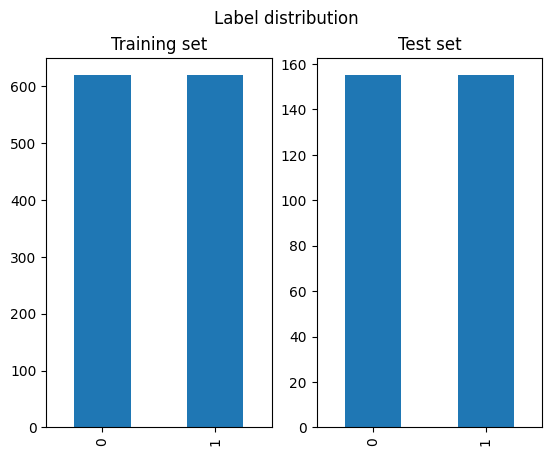

In [4]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('rm21_balanced.csv')
display(df)

y = df['Label'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(df['text'].values, y, test_size=0.2, random_state=642, stratify=y)
print(f"Training set size: {len(X_train_raw)}")
print(f"Test set size: {len(X_test_raw)}")

plt.figure()
plt.suptitle("Label distribution")
plt.subplot(1, 2, 1)
pd.Series(y_train).value_counts().plot(kind='bar')
plt.title("Training set")
plt.subplot(1, 2, 2)
pd.Series(y_test).value_counts().plot(kind='bar')
plt.title("Test set")
plt.show()

## Preprocesamiento

En los modelos de lenguaje modernos como BERT y sus sucesores, el preprocesamiento tradicional del texto (como la eliminación de stopwords, lematización o stemming) ya no es necesario ni recomendable.

Estos modelos están diseñados para entender el contexto y la estructura del lenguaje tal como aparece en el texto crudo, incluyendo palabras funcionales que aportan significado contextual.

Sin embargo, sí es común limpiar el texto de artefactos no lingüísticos, como etiquetas HTML, códigos de escape, URLs, o caracteres especiales irrelevantes.


Conservar el texto original permite al modelo aprovechar al máximo su capacidad contextual y semántica.



In [5]:
import re
import html

def clean_text(text):
    # Decodificar entidades HTML
    text = html.unescape(text)
    # Eliminar etiquetas HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # Normalizar espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [6]:
train_docs = [clean_text(doc) for doc in X_train_raw]
test_docs = [clean_text(doc) for doc in X_test_raw]

# Prompting

## Modelo

Probemos algunos modelos:

* [Phi-3.5-mini-instruct](https://huggingface.co/microsoft/Phi-3.5-mini-instruct): Modelo de Microsoft con 3.8B parámetros, 128K tokens context length, vocabulario de 32064 tokens, entrenado en agosto/2024.
* [Qwen2.5-1.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct): Modelo de Qwen con 1.54B parámetros, 32,768 tokens context length, Multilingual support for over 29 languages.

Observa que ahora usamos la clase Clase `AutoModelForCausalLM` de HuggingFace Transformers, es para modelos de lenguaje generativo. Carga automáticamente la arquitectura correcta según el nombre del modelo.

Tipos de tarea:
* Generación de texto
* Completación de prompts
* Chatbots
* Predicción del siguiente token

In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# model_name = "Qwen/Qwen2.5-1.5B-Instruct"
# model_name = "Qwen/Qwen-7B-Chat"
# model_name = "mosaicml/mpt-7b""
# model_name = "tiiuae/falcon-7b-instruct"
model_name = "microsoft/Phi-3.5-mini-instruct"
# model_name = "HuggingFaceH4/zephyr-7b-beta"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

## Sentiment Analysis

### Zero shot

Con GPU y 200 ejemplos, tarda alrededor de 1 minuto

In [8]:
train_docs[0]

'Bonito. Tenía muchas ganas de conocer el teatro. Por dentro, lamentablemente no cumplió mis expectativas. Es más bello el teatro de NY donde fuimos a ver la obra de teatro del Rey León. Pero, bueno es un teatro con historia. Y es importante conocerlo y aprender sobre la cultura de Gusnajuato. Por fuera es mega espectacular.'

Haremos este [prompt](https://claude.ai/share/3b52a333-a017-4de0-9970-201b824a2b52) de forma iterada, solamente sobre un número pequeño de ejemplos

In [10]:
prompt = "Hi, what is an LLM?"
messages = [
    {'role': 'system', 'content': 'You are a helpful assistant.'},
    {'role': 'user', 'content': prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=32
)
generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids) # ¿Qué hace esta linea?
    ]
response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(response)

Hello! LLM stands for "Legal Legal Assistant" or "Language Learning Model," depending on the context.

1. **Legal


In [11]:
import time

responses = []

num_training_docs = len(test_docs)

start = time.time()
for k,sentence in enumerate(test_docs):
    prompt = "I want to perform a binary sentiment analysis task on the following text, determine if the sentiment is positive or negative. Respond only 'positive' or 'negative'. The text is: " + sentence
    messages = [
        {"role": "system", "content": "You are a helpful assistant performing binary sentiment analysis."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=16
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    if k%20==0:
        print(f"{k+1}/{num_training_docs}")
    responses.append(response)   # ¿Qué pasa si el modelo responde algo diferente a solamente 'positive' o 'negative'?

zero_shot_time = time.time() - start
print(f"Tiempo de ejecución: {zero_shot_time} segundos")
print(responses[:10])

1/310
21/310
41/310
61/310
81/310
101/310
121/310
141/310
161/310
181/310
201/310
221/310
241/310
261/310
281/310
301/310
Tiempo de ejecución: 204.27491545677185 segundos
['neutral', 'negative', 'negative', 'negative', 'positive', 'positive', 'positive', 'positive', 'negative', 'positive']


### Few shot

Obtenemos unos pocos documentos de ejemplo

In [36]:
y_test[:10]

array([0, 0, 0, 0, 0, 1, 1, 1, 0, 0])

In [37]:
sample_docs = [test_docs[j] for j in [0,5]]
sample_labels = [y_test[j] for j in [0,5]]

In [38]:
print(sample_docs)
print(sample_labels)

['Tienes que ir. Es un lugar bonito, pero no es nada wow. Ahí la cosa es ir a tomarte la foto. Si visitas Guanajuato, es un must en tu recorrido. Ahí hay un señor que cobra 100 pesos por tomarte una foto, que imprime en cuestión de minutos en una hoja especial que cuenta detalles sobre el lugar.', 'Belleza interior. Esta iglesia es impresionante sobre todo por dentro, muy elegante. Cuenta con un hermoso órgano, que pude escuchar en el festival de música sacra (que fue a finales de marzo). Su sonido te transporta a otra época, es una gran experiencia.']
[np.int64(0), np.int64(1)]


In [39]:
responses = []

label_to_text = {0: "negative", 1: "positive"}

start = time.time()

for k, sentence in enumerate(test_docs):
    prompt = ""
    for label, text in zip(sample_labels[1:], sample_docs[1:]):
        prompt += f"\n{text} // {label_to_text[label]}\n"
    prompt += f"\n{sentence} // "

    messages = [
        {"role": "system", "content": "You are a helpful assistant performing binary sentiment analysis. You must respond ONLY with 'positive' or 'negative', nothing else."},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=3,  # Reducido ya que solo necesitamos una palabra
        num_return_sequences=1,
        do_sample=False,   # Para hacerlo más determinista
        pad_token_id=tokenizer.eos_token_id
    )

    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # Nuevo componente: ----------------------------------------
    # Limpiar la respuesta para obtener solo "positive" o "negative"
    response = response.strip().lower()
    if "positive" in response:
        response = "positive"
    elif "negative" in response:
        response = "negative"
    else:
        # Si no es claro, usar una respuesta por defecto
        response = "unknown"

    if k%20==0:
        print(f"{k+1}/{len(test_docs)}: {response}")
    responses.append(response)

few_shot_time = time.time() - start
print(f"Tiempo de ejecución: {few_shot_time} segundos")

1/310: positive
21/310: positive
41/310: negative
61/310: negative
81/310: negative
101/310: positive
121/310: positive
141/310: positive
161/310: positive
181/310: positive
201/310: positive
221/310: positive
241/310: negative
261/310: positive
281/310: positive
301/310: negative
Tiempo de ejecución: 267.5061686038971 segundos


## Evaluación

In [13]:
def encode(x):
    if x.lower() == "positive":
        return 1
    else:
        return 0  # ¿y si contesta otra cosa diferente de <negative>?

y_pred_one_shot = [encode(x) for x in responses]

Accuracy: 0.8161290322580645


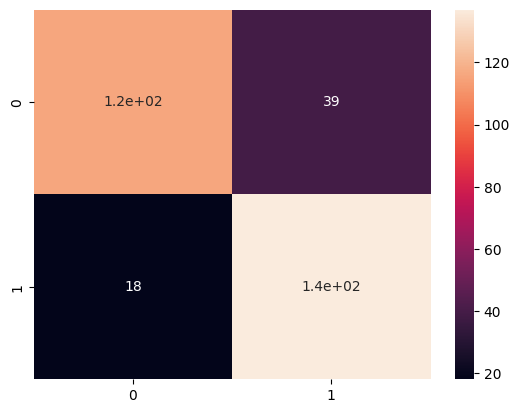

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

zero_shot_accuracy = accuracy_score(y_test, y_pred_one_shot)
print(f"Accuracy: {zero_shot_accuracy}")
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_one_shot), annot=True)
plt.show()

Accuracy: 0.7741935483870968


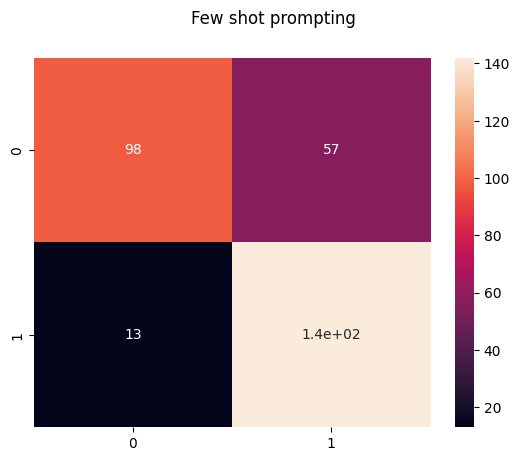

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred_few_shot = [encode(x) for x in responses]

few_shot_accuracy = accuracy_score(y_test, y_pred_few_shot)
print(f"Accuracy: {few_shot_accuracy}")
plt.figure()
plt.suptitle("Few shot prompting")
sns.heatmap(confusion_matrix(y_test, y_pred_few_shot), annot=True)
plt.show()

# HF Sentiment Analysis Pipeline

In [30]:
from transformers import pipeline
import time

start = time.time()
sentiment_pipeline = pipeline("sentiment-analysis",
                              model='ignacio-ave/beto-sentiment-analysis-spanish')
hf_pred_labels = sentiment_pipeline(test_docs)
hf_time = time.time() - start
print(f"Tiempo de ejecución: {hf_time} segundos")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tiempo de ejecución: 4.222471237182617 segundos


In [31]:
hf_pred_labels[:10]

[{'label': 'VERY POSITIVE', 'score': 0.900096595287323},
 {'label': 'NEGATIVE', 'score': 0.878648579120636},
 {'label': 'NEUTRAL', 'score': 0.8624028563499451},
 {'label': 'NEGATIVE', 'score': 0.5990414619445801},
 {'label': 'NEUTRAL', 'score': 0.8781384229660034},
 {'label': 'VERY POSITIVE', 'score': 0.9900374412536621},
 {'label': 'VERY POSITIVE', 'score': 0.971746563911438},
 {'label': 'VERY POSITIVE', 'score': 0.9890316128730774},
 {'label': 'POSITIVE', 'score': 0.6360743045806885},
 {'label': 'POSITIVE', 'score': 0.6776614189147949}]

In [32]:
def hf_encode(x):
    if 'positive' in x.lower():
        return 1
    else:
        return 0

hf_pred_labels = [x['label'] for x in hf_pred_labels]
hf_pred_labels = [hf_encode(x) for x in hf_pred_labels]

Accuracy: 0.7677419354838709


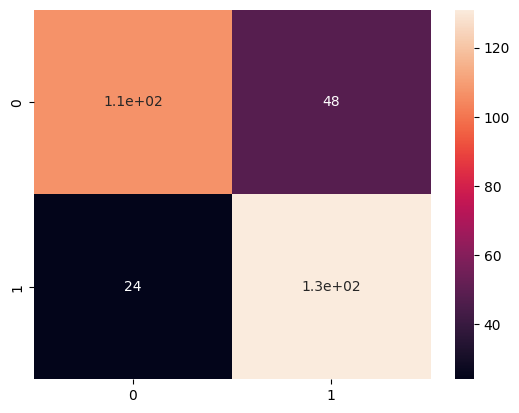

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

hf_accuracy = accuracy_score(y_test, hf_pred_labels)
print(f"Accuracy: {hf_accuracy}")
plt.figure()
sns.heatmap(confusion_matrix(y_test, hf_pred_labels), annot=True)
plt.show()

# Comparación de enfoques

Comparemos con un baseline

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Tiempo de ejecución: 2.2095065116882324 segundos
Accuracy: 0.7516129032258064


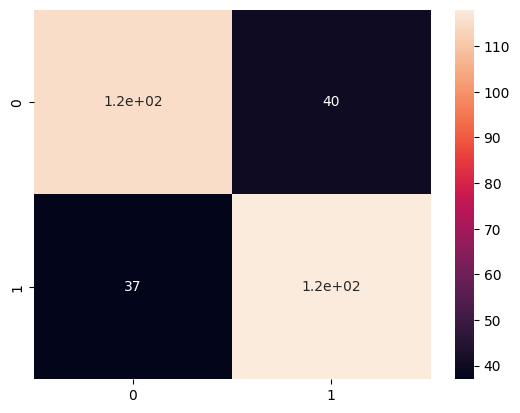

In [44]:
from sentence_transformers import SentenceTransformer
from sklearn.svm import SVC

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
start = time.time()
X_train = model.encode(train_docs)
X_test = model.encode(test_docs)
clf = SVC(kernel='linear')
clf.fit(X_train, y_train)
y_pred_baseline = clf.predict(X_test)
baseline_time = time.time() - start
print(f"Tiempo de ejecución: {baseline_time} segundos")

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Accuracy: {baseline_accuracy}")
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_baseline), annot=True)
plt.show()

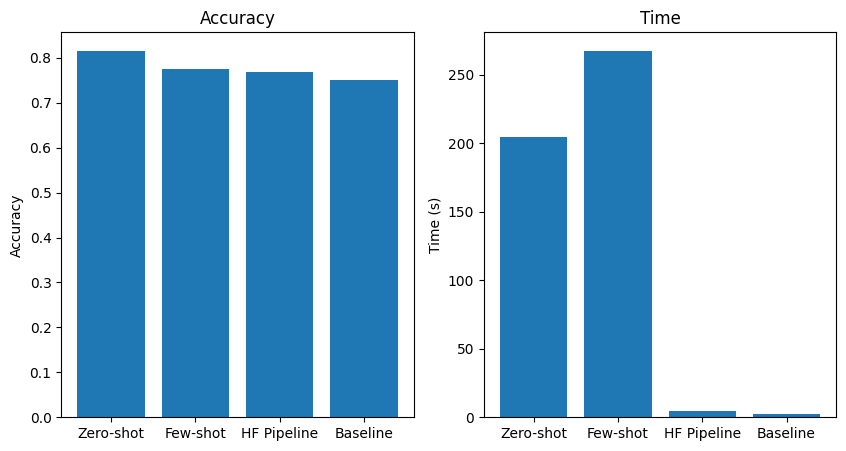

In [45]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(
    ["Zero-shot", "Few-shot","HF Pipeline","Baseline"],
    [zero_shot_accuracy, few_shot_accuracy, hf_accuracy,baseline_accuracy]
)
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.subplot(1, 2, 2)
plt.bar(
    ["Zero-shot", "Few-shot","HF Pipeline","Baseline"],
    [zero_shot_time, few_shot_time, hf_time,baseline_time]
)
plt.ylabel("Time (s)")
plt.title("Time")
plt.show()

## Further Explorations

Está técnica *Dynamic Zero-Shot Categorization* podríamos usarla en más tareas:
* Topic Modeling
* Information Extraction

🔴 ¿Cómo funcionaría el prompting aquí?